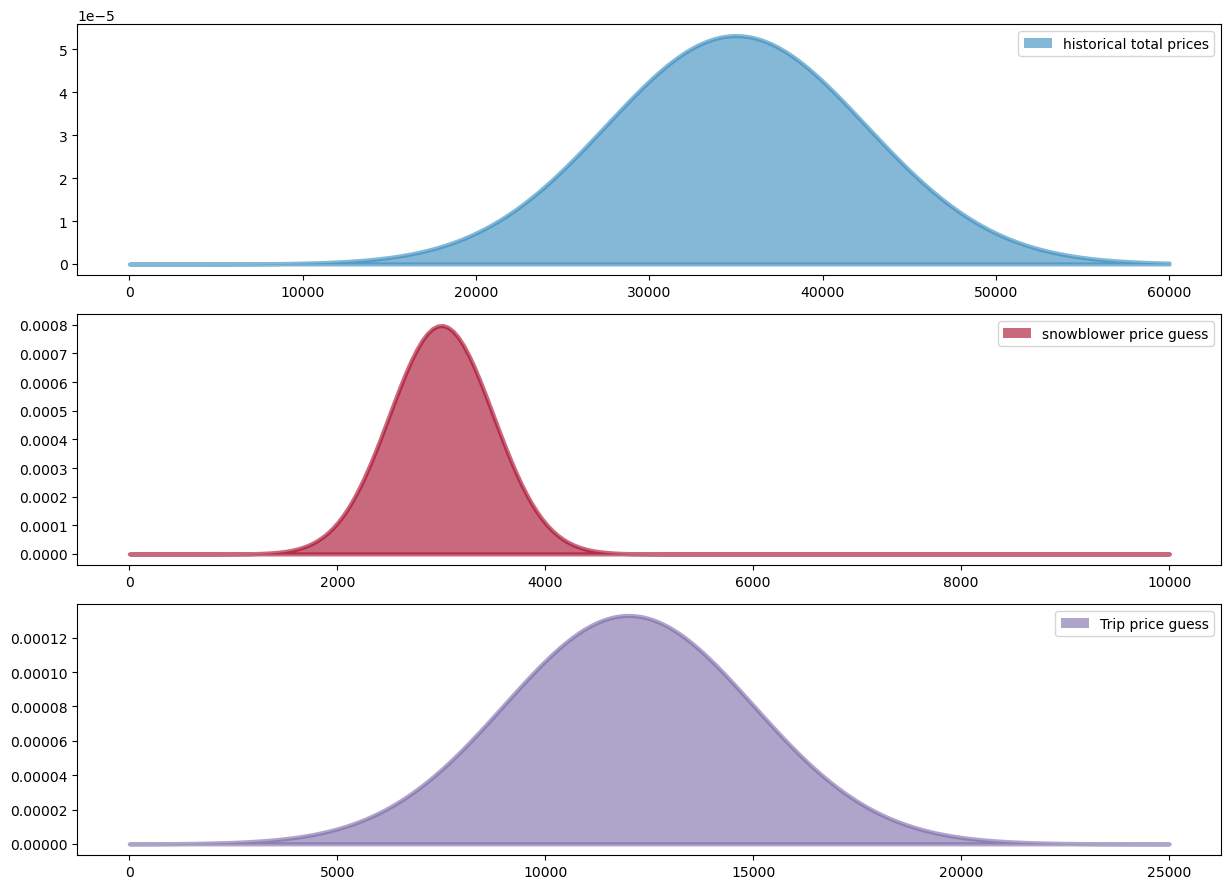

C:\Users\user\AppData\Local\Temp\ipykernel_7736\1412538153.py:130: FutureWarning: `return_inferencedata=False` is deprecated and will be removed in a future release. Use the default `return_inferencedata=True` and work with the returned `InferenceData` object.
  trace = pm.sample(
Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [true_price]
>Metropolis: [first_prize]
>Metropolis: [second_prize]


Output()

Sampling 2 chains for 10_000 tune and 50_000 draw iterations (20_000 + 100_000 draws total) took 86 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


サンプル数: 100000

true_price の事後分布
平均      : 19891.51562384723
中央値    : 19900.29484478439
標準偏差  : 3741.7964257554277
最小値    : 2674.694601740346
最大値    : 35666.03653817947
95%信用区間: [12457.76193256 27168.63479376]

first_prize の事後分布
平均      : 3071.3824830488
中央値    : 3069.4621938810437
標準偏差  : 498.44886949349154
最小値    : 980.0895676369687
最大値    : 5156.836570794697
95%信用区間: [2096.39112743 4058.81607941]

second_prize の事後分布
平均      : 14398.874029204331
中央値    : 14406.149586493346
標準偏差  : 2835.2151918724007
最小値    : 2913.1753622658784
最大値    : 27198.550389899927
95%信用区間: [ 8798.18795021 19975.02311327]

estimated_total の事後分布
平均      : 17470.25651225313
中央値    : 17471.59015337948
標準偏差  : 2870.23324152977
最小値    : 5831.52027703676
最大値    : 30162.30271214317
95%信用区間: [11806.57003831 23109.69733041]


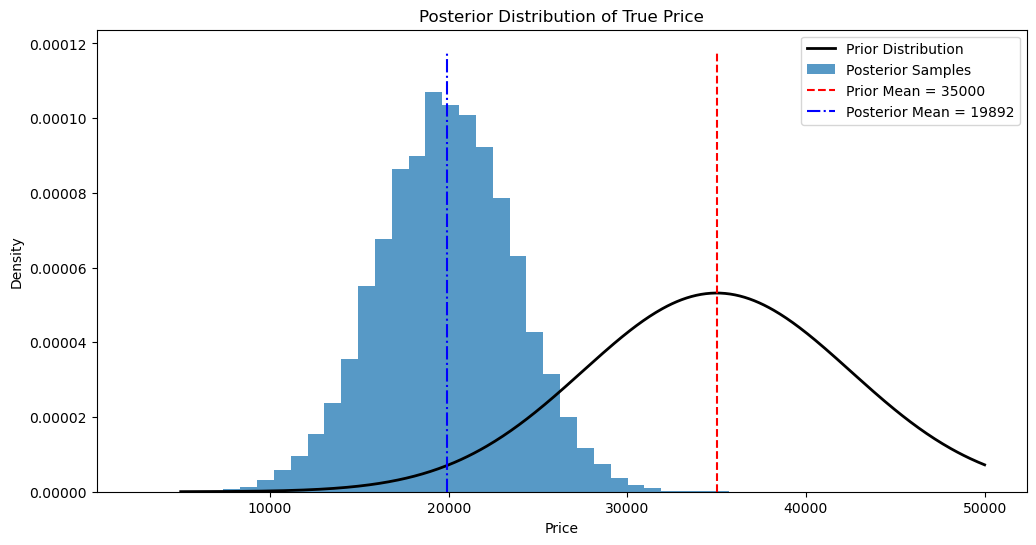

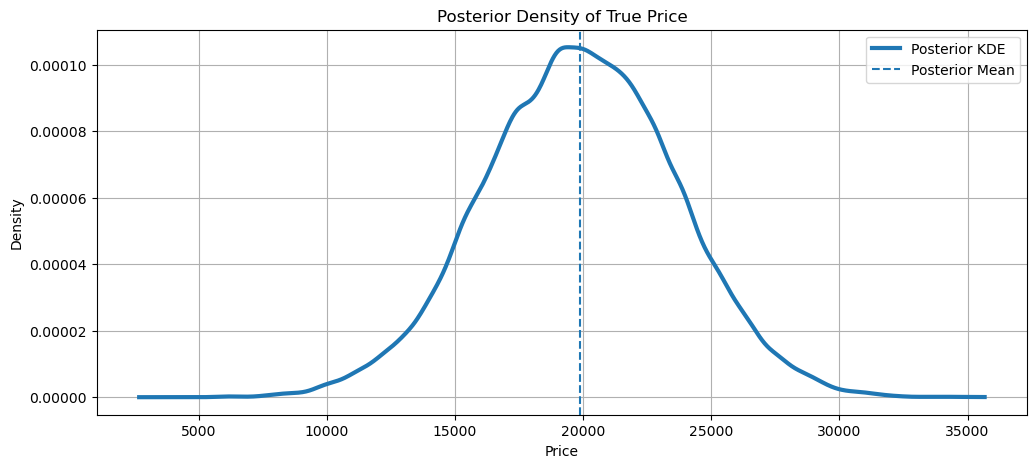

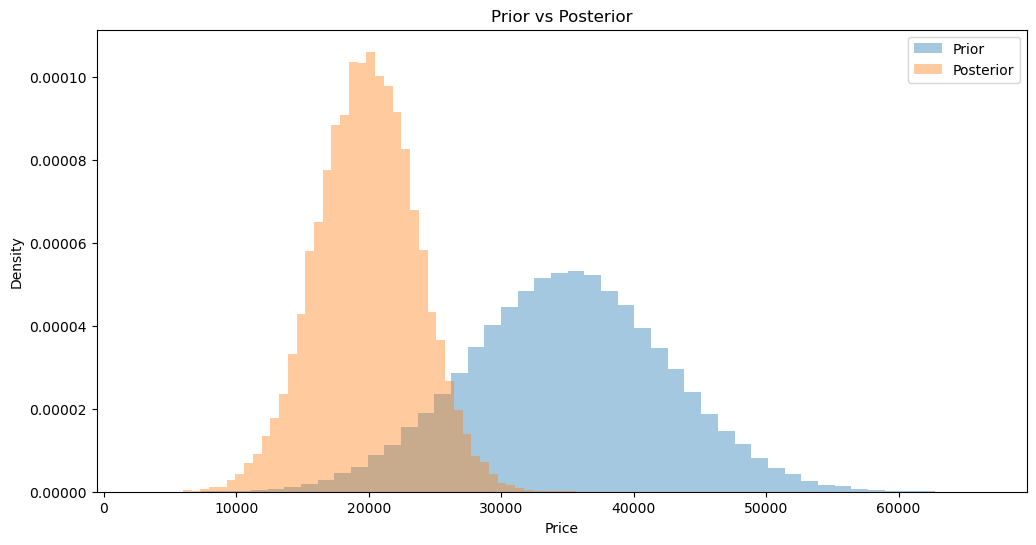

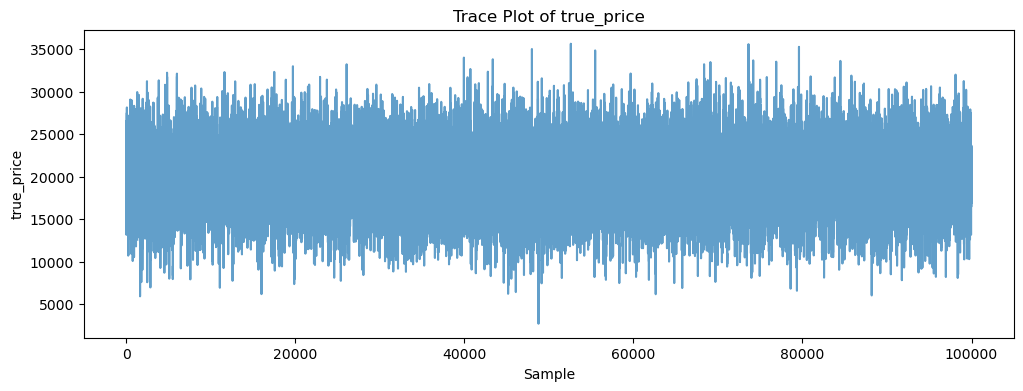

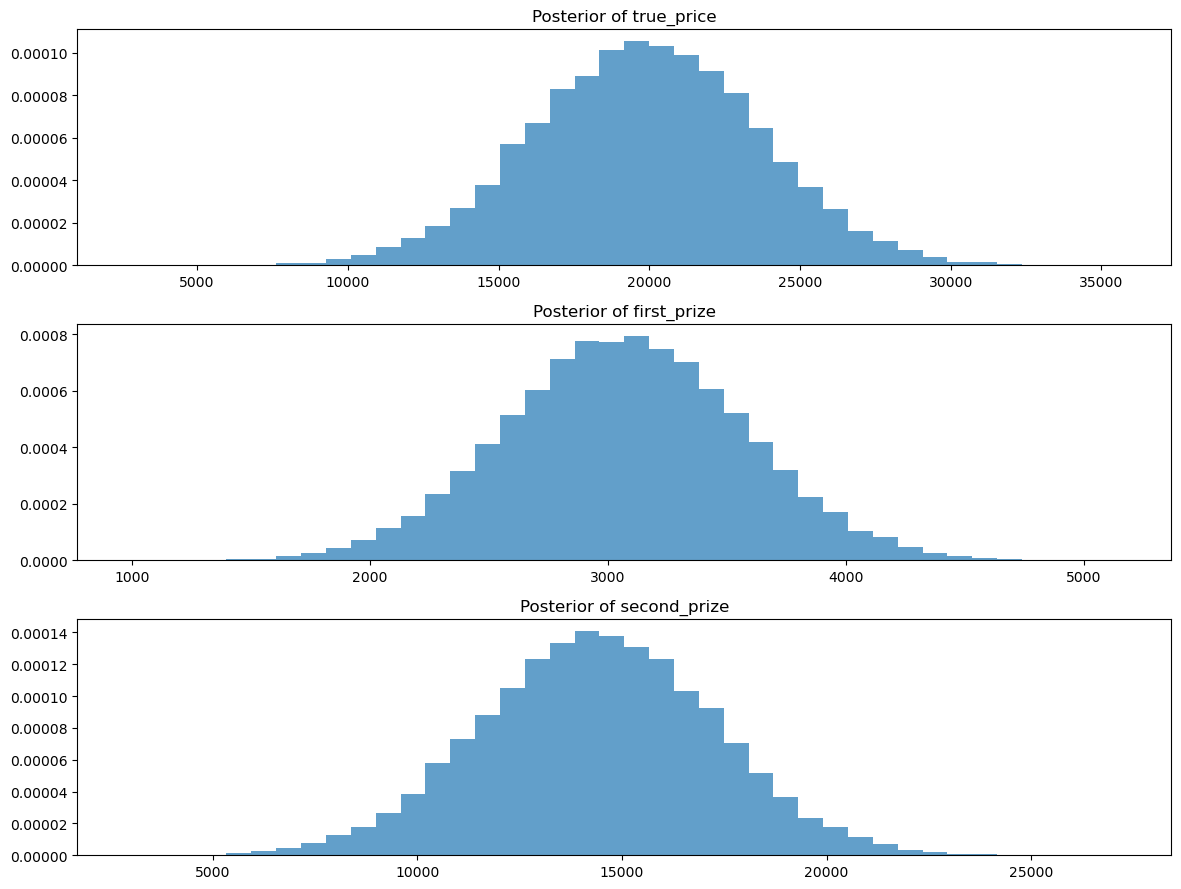

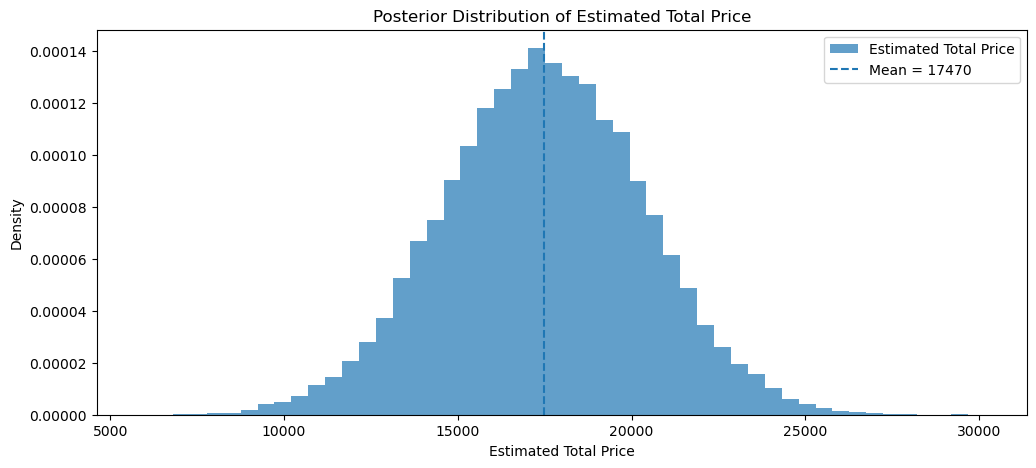

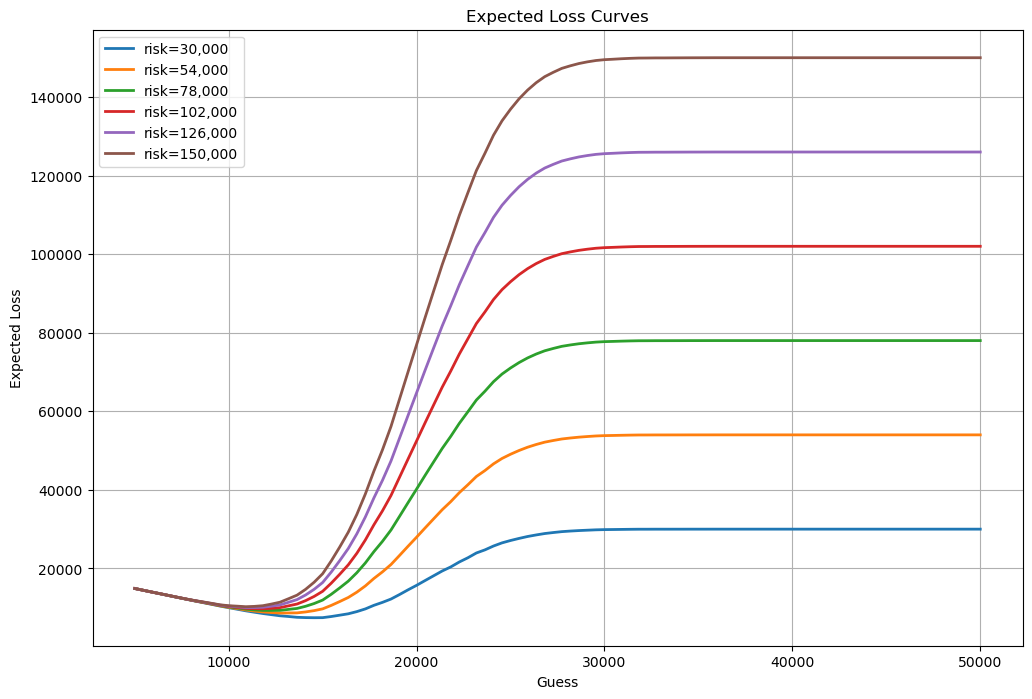

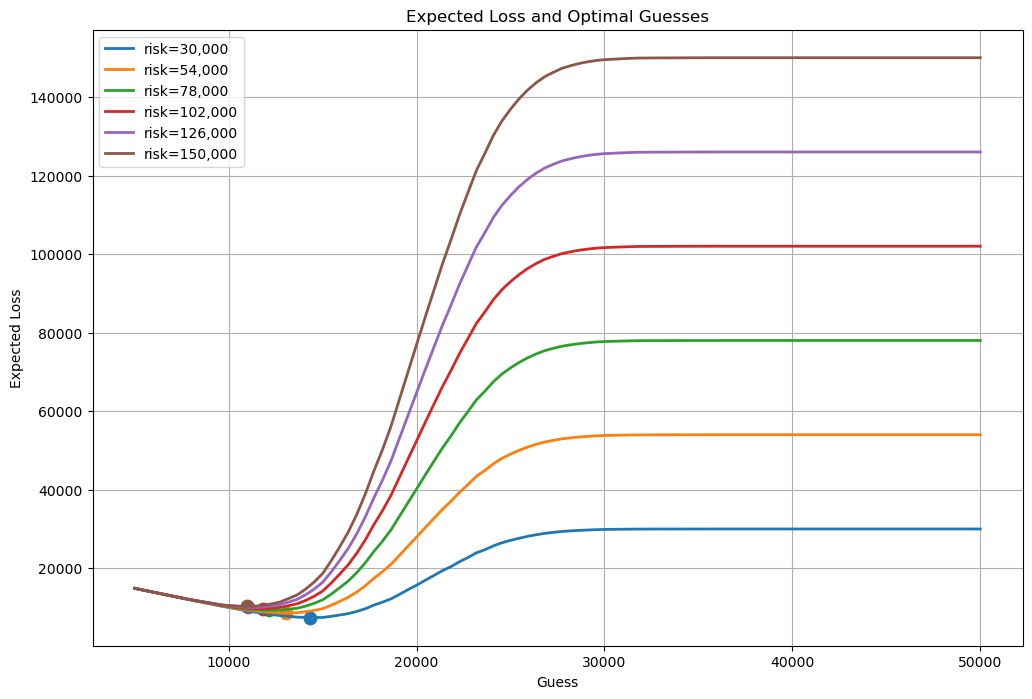


===== Optimal Guess by Grid Search =====

risk=30,000 -> best_guess=14,545
risk=54,000 -> best_guess=12,727
risk=78,000 -> best_guess=12,273
risk=102,000 -> best_guess=11,818
risk=126,000 -> best_guess=11,364
risk=150,000 -> best_guess=10,909

===== Optimal Guess by scipy.optimize =====

risk=30,000 -> best_guess=14,324.53
risk=54,000 -> best_guess=13,060.28
risk=78,000 -> best_guess=12,143.69
risk=102,000 -> best_guess=11,819.68
risk=126,000 -> best_guess=11,039.14
risk=150,000 -> best_guess=10,972.37


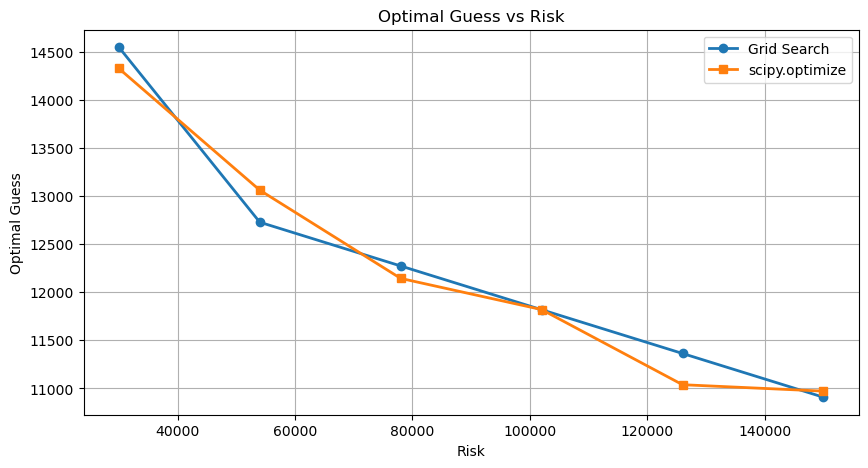

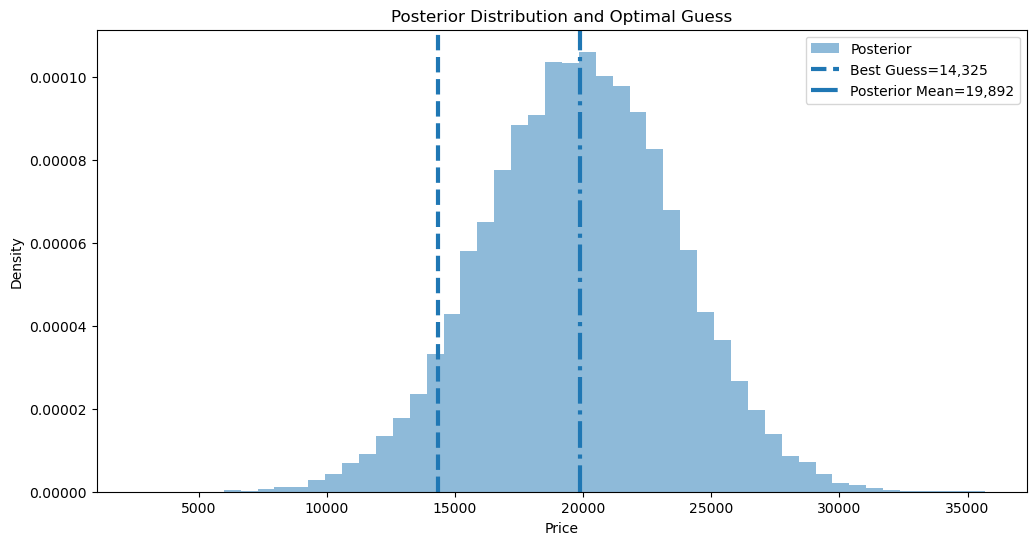

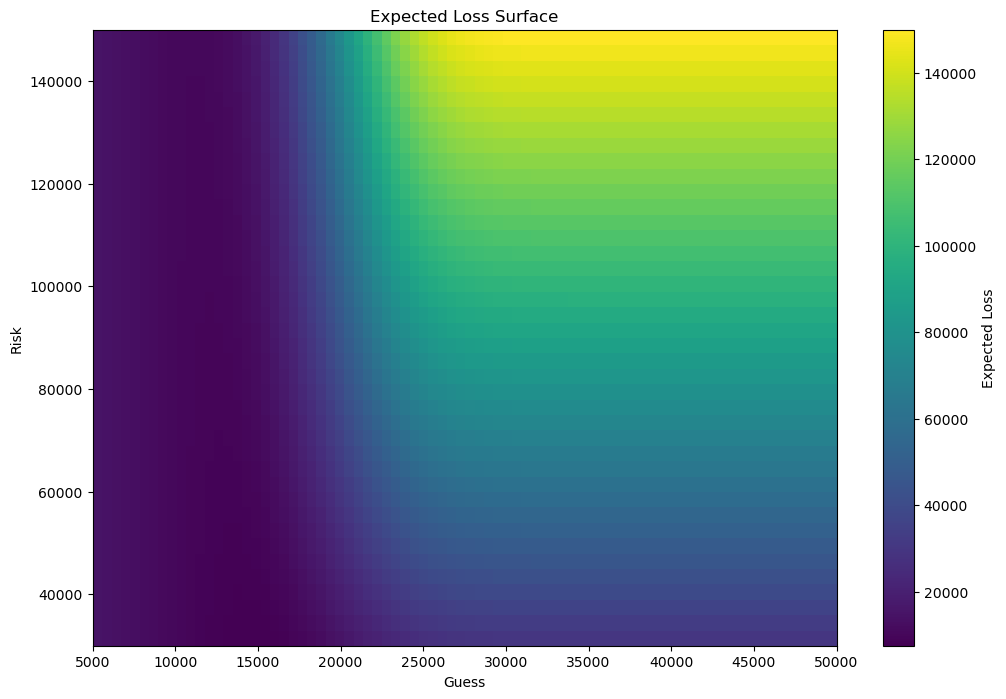

In [12]:
# =====================================================
# Bayesian Price Estimation
# PyMC5 / Matplotlib最新版対応
# ArviZなし・prop_cyclerなし 完全版
# =====================================================

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.optimize as sop
import pymc as pm

from scipy.stats import gaussian_kde
from IPython.core.pylabtools import figsize

figsize(12.5, 9)

# =====================================================
# 1. 事前分布・価格予想分布の可視化
# =====================================================

norm_pdf = stats.norm.pdf

plt.figure(figsize=(12.5, 9))

plt.subplot(311)
x = np.linspace(0, 60000, 200)

sp1 = plt.fill_between(
    x,
    0,
    norm_pdf(x, 35000, 7500),
    color="#348ABD",
    lw=3,
    alpha=0.6,
    label="historical total prices"
)

p1 = plt.Rectangle((0, 0), 1, 1, fc=sp1.get_facecolor()[0])
plt.legend([p1], [sp1.get_label()])


plt.subplot(312)
x = np.linspace(0, 10000, 200)

sp2 = plt.fill_between(
    x,
    0,
    norm_pdf(x, 3000, 500),
    color="#A60628",
    lw=3,
    alpha=0.6,
    label="snowblower price guess"
)

p2 = plt.Rectangle((0, 0), 1, 1, fc=sp2.get_facecolor()[0])
plt.legend([p2], [sp2.get_label()])


plt.subplot(313)
x = np.linspace(0, 25000, 200)

sp3 = plt.fill_between(
    x,
    0,
    norm_pdf(x, 12000, 3000),
    color="#7A68A6",
    lw=3,
    alpha=0.6,
    label="Trip price guess"
)

p3 = plt.Rectangle((0, 0), 1, 1, fc=sp3.get_facecolor()[0])
plt.legend([p3], [sp3.get_label()])

plt.tight_layout()
plt.show()


# =====================================================
# 2. パラメータ設定
# =====================================================

data_mu = [3000, 12000]
data_std = [500, 3000]

mu_prior = 35000
std_prior = 7500


# =====================================================
# 3. PyMCモデル構築
# =====================================================

with pm.Model() as model:

    true_price = pm.Normal(
        "true_price",
        mu=mu_prior,
        sigma=std_prior
    )

    prize_1 = pm.Normal(
        "first_prize",
        mu=data_mu[0],
        sigma=data_std[0]
    )

    prize_2 = pm.Normal(
        "second_prize",
        mu=data_mu[1],
        sigma=data_std[1]
    )

    price_estimate = prize_1 + prize_2

    pm.Potential(
        "error",
        pm.logp(
            pm.Normal.dist(
                mu=price_estimate,
                sigma=3000
            ),
            true_price
        )
    )

    trace = pm.sample(
        draws=50000,
        tune=10000,
        chains=2,
        step=pm.Metropolis(),
        random_seed=42,
        return_inferencedata=False
    )


# =====================================================
# 4. サンプル抽出
# =====================================================

price_trace = trace.get_values("true_price")
first_prize_trace = trace.get_values("first_prize")
second_prize_trace = trace.get_values("second_prize")

estimated_total_trace = first_prize_trace + second_prize_trace

print("サンプル数:", len(price_trace))


# =====================================================
# 5. 要約統計
# =====================================================

def print_summary(name, values):
    print()
    print(name)
    print("平均      :", np.mean(values))
    print("中央値    :", np.median(values))
    print("標準偏差  :", np.std(values))
    print("最小値    :", np.min(values))
    print("最大値    :", np.max(values))
    print("95%信用区間:", np.percentile(values, [2.5, 97.5]))


print_summary("true_price の事後分布", price_trace)
print_summary("first_prize の事後分布", first_prize_trace)
print_summary("second_prize の事後分布", second_prize_trace)
print_summary("estimated_total の事後分布", estimated_total_trace)


# =====================================================
# 6. true_price の事後分布
# =====================================================

plt.figure(figsize=(12, 6))

x = np.linspace(5000, 50000, 500)

plt.plot(
    x,
    stats.norm.pdf(x, mu_prior, std_prior),
    c="black",
    lw=2,
    label="Prior Distribution"
)

_hist = plt.hist(
    price_trace,
    bins=35,
    density=True,
    histtype="stepfilled",
    alpha=0.75,
    label="Posterior Samples"
)

plt.vlines(
    mu_prior,
    0,
    np.max(_hist[0]) * 1.1,
    colors="red",
    linestyles="--",
    label=f"Prior Mean = {mu_prior:.0f}"
)

plt.vlines(
    np.mean(price_trace),
    0,
    np.max(_hist[0]) * 1.1,
    colors="blue",
    linestyles="-.",
    label=f"Posterior Mean = {np.mean(price_trace):.0f}"
)

plt.xlabel("Price")
plt.ylabel("Density")
plt.title("Posterior Distribution of True Price")
plt.legend()
plt.show()


# =====================================================
# 7. KDE表示
# =====================================================

plt.figure(figsize=(12, 5))

kde = gaussian_kde(price_trace)

x = np.linspace(
    np.min(price_trace),
    np.max(price_trace),
    1000
)

plt.plot(
    x,
    kde(x),
    linewidth=3,
    label="Posterior KDE"
)

plt.axvline(
    np.mean(price_trace),
    linestyle="--",
    label="Posterior Mean"
)

plt.xlabel("Price")
plt.ylabel("Density")
plt.title("Posterior Density of True Price")
plt.legend()
plt.grid(True)
plt.show()


# =====================================================
# 8. 事前分布と事後分布の比較
# =====================================================

plt.figure(figsize=(12, 6))

prior_samples = np.random.normal(
    mu_prior,
    std_prior,
    size=len(price_trace)
)

plt.hist(
    prior_samples,
    bins=50,
    density=True,
    alpha=0.4,
    label="Prior"
)

plt.hist(
    price_trace,
    bins=50,
    density=True,
    alpha=0.4,
    label="Posterior"
)

plt.xlabel("Price")
plt.ylabel("Density")
plt.title("Prior vs Posterior")
plt.legend()
plt.show()


# =====================================================
# 9. MCMCトレース確認
# =====================================================

plt.figure(figsize=(12, 4))

plt.plot(
    price_trace,
    alpha=0.7
)

plt.xlabel("Sample")
plt.ylabel("true_price")
plt.title("Trace Plot of true_price")
plt.show()


# =====================================================
# 10. 3変数のヒストグラム
# =====================================================

plt.figure(figsize=(12, 9))

plt.subplot(311)
plt.hist(
    price_trace,
    bins=40,
    density=True,
    alpha=0.7
)
plt.title("Posterior of true_price")

plt.subplot(312)
plt.hist(
    first_prize_trace,
    bins=40,
    density=True,
    alpha=0.7
)
plt.title("Posterior of first_prize")

plt.subplot(313)
plt.hist(
    second_prize_trace,
    bins=40,
    density=True,
    alpha=0.7
)
plt.title("Posterior of second_prize")

plt.tight_layout()
plt.show()


# =====================================================
# 11. 予想合計価格の分布
# =====================================================

plt.figure(figsize=(12, 5))

plt.hist(
    estimated_total_trace,
    bins=50,
    density=True,
    alpha=0.7,
    label="Estimated Total Price"
)

plt.axvline(
    np.mean(estimated_total_trace),
    linestyle="--",
    label=f"Mean = {np.mean(estimated_total_trace):.0f}"
)

plt.xlabel("Estimated Total Price")
plt.ylabel("Density")
plt.title("Posterior Distribution of Estimated Total Price")
plt.legend()
plt.show()


# =====================================================
# 12. 損失関数
# =====================================================

def showdown_loss(guess, true_price, risk):
    """
    guess      : 予想価格
    true_price : true_price posterior samples
    risk       : 高く見積もった時のペナルティ
    """

    true_price = np.asarray(true_price)

    loss = np.zeros_like(true_price, dtype=float)

    over_mask = guess > true_price

    loss[~over_mask] = np.abs(
        guess - true_price[~over_mask]
    )

    close_mask = np.abs(
        true_price - guess
    ) <= 250

    loss[close_mask] = (
        -2.0 * true_price[close_mask]
    )

    loss[over_mask] = risk

    return loss


def expected_loss(guess, risk):
    """
    期待損失
    scipy.optimize 用に guess が配列でも動くようにする
    """

    guess = np.asarray(guess).item()

    return showdown_loss(
        guess,
        price_trace,
        risk
    ).mean()


# =====================================================
# 13. 期待損失曲線
# =====================================================

guesses = np.linspace(
    5000,
    50000,
    100
)

risks = np.linspace(
    30000,
    150000,
    6
)

plt.figure(figsize=(12, 8))

best_guesses_grid = []

for risk in risks:

    losses = []

    for guess in guesses:

        loss = expected_loss(
            guess,
            risk
        )

        losses.append(loss)

    losses = np.array(losses)

    best_guess = guesses[
        np.argmin(losses)
    ]

    best_guesses_grid.append(best_guess)

    plt.plot(
        guesses,
        losses,
        linewidth=2,
        label=f"risk={risk:,.0f}"
    )

plt.xlabel("Guess")
plt.ylabel("Expected Loss")
plt.title("Expected Loss Curves")
plt.grid(True)
plt.legend()
plt.show()


# =====================================================
# 14. scipy.optimize による最適予想価格
# =====================================================

plt.figure(figsize=(12, 8))

best_guesses_opt = []

for risk in risks:

    min_result = sop.fmin(
        expected_loss,
        x0=15000,
        args=(risk,),
        disp=False
    )

    best_guess = float(min_result[0])
    best_guesses_opt.append(best_guess)

    results = [
        expected_loss(g, risk)
        for g in guesses
    ]

    plt.plot(
        guesses,
        results,
        linewidth=2,
        label=f"risk={risk:,.0f}"
    )

    plt.scatter(
        best_guess,
        expected_loss(best_guess, risk),
        s=80
    )

plt.title("Expected Loss and Optimal Guesses")
plt.xlabel("Guess")
plt.ylabel("Expected Loss")
plt.legend()
plt.grid(True)
plt.show()


# =====================================================
# 15. 最適予想価格の表示
# =====================================================

print()
print("===== Optimal Guess by Grid Search =====")
print()

for risk, guess in zip(
    risks,
    best_guesses_grid
):

    print(
        f"risk={risk:,.0f} -> best_guess={guess:,.0f}"
    )


print()
print("===== Optimal Guess by scipy.optimize =====")
print()

for risk, guess in zip(
    risks,
    best_guesses_opt
):

    print(
        f"risk={risk:,.0f} -> best_guess={guess:,.2f}"
    )


# =====================================================
# 16. Risk と最適予想価格
# =====================================================

plt.figure(figsize=(10, 5))

plt.plot(
    risks,
    best_guesses_grid,
    marker="o",
    linewidth=2,
    label="Grid Search"
)

plt.plot(
    risks,
    best_guesses_opt,
    marker="s",
    linewidth=2,
    label="scipy.optimize"
)

plt.xlabel("Risk")
plt.ylabel("Optimal Guess")
plt.title("Optimal Guess vs Risk")
plt.legend()
plt.grid(True)
plt.show()


# =====================================================
# 17. 事後分布と最適予想価格
# =====================================================

plt.figure(figsize=(12, 6))

plt.hist(
    price_trace,
    bins=50,
    density=True,
    alpha=0.5,
    label="Posterior"
)

best_guess = best_guesses_opt[0]

plt.axvline(
    best_guess,
    linestyle="--",
    linewidth=3,
    label=f"Best Guess={best_guess:,.0f}"
)

plt.axvline(
    np.mean(price_trace),
    linestyle="-.",
    linewidth=3,
    label=f"Posterior Mean={np.mean(price_trace):,.0f}"
)

plt.xlabel("Price")
plt.ylabel("Density")
plt.title("Posterior Distribution and Optimal Guess")
plt.legend()
plt.show()


# =====================================================
# 18. 期待損失サーフェス
# =====================================================

risk_grid = np.linspace(
    30000,
    150000,
    40
)

guess_grid = np.linspace(
    5000,
    50000,
    80
)

loss_matrix = np.zeros(
    (
        len(risk_grid),
        len(guess_grid)
    )
)

for i, risk in enumerate(risk_grid):

    for j, guess in enumerate(guess_grid):

        loss_matrix[i, j] = expected_loss(
            guess,
            risk
        )

plt.figure(figsize=(12, 8))

plt.imshow(
    loss_matrix,
    aspect="auto",
    origin="lower",
    extent=[
        guess_grid.min(),
        guess_grid.max(),
        risk_grid.min(),
        risk_grid.max()
    ]
)

plt.colorbar(
    label="Expected Loss"
)

plt.xlabel("Guess")
plt.ylabel("Risk")
plt.title("Expected Loss Surface")
plt.show()